In [1]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from matplotlib.pyplot import figure

In [2]:
img_size = 128

In [3]:
def convexhull_mask(mask):
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
    
    points = []
    for i in range(img_size):
        for j in range(img_size):
            if mask[i][j] == 255:
                points.append((j,i))
    points = np.array(points)
    hull = cv2.convexHull(points)
    hulls = np.array([hull])
    
    w,h = mask.shape
    ground = np.zeros((w,h)) 
    figure(figsize = (18,16), dpi = 30)
    cv2.drawContours(ground, hulls, -1, (255,0,0), 3)
    plt.close()
    
    new_mask = np.zeros((img_size,img_size))
    for i in range(img_size):
        minn = img_size + 10
        maxx = 0
        for j in range(img_size):
            if ground[i][j] == 255:
                minn = min(minn, j)
                maxx = max(maxx, j)
        for j in range(minn, maxx + 1):
            new_mask[i][j] = 255

    return new_mask

def segmentation_data_loading_cxr(path):
    images = []
    for image in os.listdir(path):
        if image == 'Thumbs.db':
            continue
        images.append(image)
    images.sort()
    
    cxrs = [] 
    for i in tqdm(range(len(images))):
        image = images[i]
        cxr = cv2.imread(os.path.join(path, image), cv2.IMREAD_GRAYSCALE)
        cxr = cv2.resize(cxr, (img_size,img_size))
        cxrs.append(cxr)
        
    return np.array(cxrs, dtype = int)

def segmentation_data_loading_mask(path):
    images = []
    for image in os.listdir(path):
        if image == 'Thumbs.db':
            continue
        images.append(image)
    images.sort()
    
    masks = [] 
    for i in tqdm(range(len(images))):
        image = images[i]
        mask = cv2.imread(os.path.join(path, image), cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (img_size,img_size))
        # mask = convexhull_mask(mask)
        masks.append(mask)
        
    return np.array(masks, dtype = int)

In [4]:
covid19_covid_cxr = segmentation_data_loading_cxr('/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/COVID/images')
covid19_covid_mask = segmentation_data_loading_mask('/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/COVID/masks')

print(np.shape(covid19_covid_cxr))
print(np.shape(covid19_covid_mask))

cxrs = covid19_covid_cxr
masks = covid19_covid_mask

del covid19_covid_cxr
del covid19_covid_mask

print(np.shape(cxrs))
print(np.shape(masks))

100%|██████████| 3616/3616 [00:23<00:00, 152.20it/s]


(3616, 128, 128)
(3616, 128, 128)
(3616, 128, 128)
(3616, 128, 128)


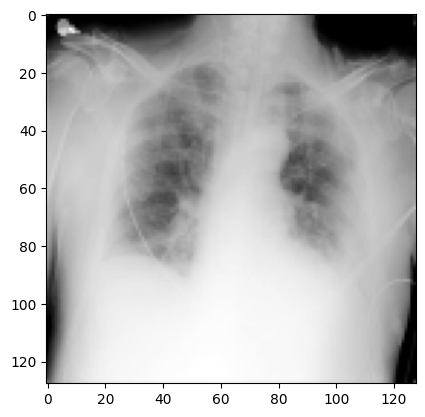

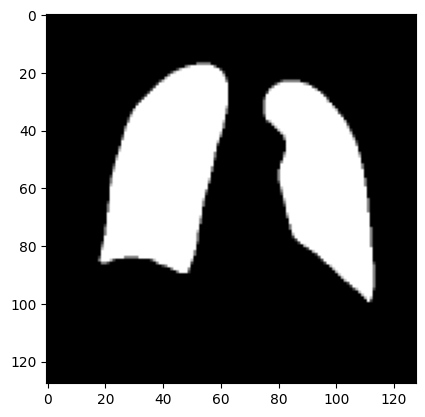

In [5]:
plt.imshow(cxrs[0], cmap='gray')
plt.show()
plt.imshow(masks[0], cmap='gray')
plt.show()

In [6]:
covid19_opacity_cxr = segmentation_data_loading_cxr('/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Lung_Opacity/images')
covid19_opacity_mask = segmentation_data_loading_mask('/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Lung_Opacity/masks')

print(np.shape(covid19_opacity_cxr))
print(np.shape(covid19_opacity_mask))

cxrs = np.concatenate((cxrs, covid19_opacity_cxr), axis = 0)
masks = np.concatenate((masks, covid19_opacity_mask), axis = 0)

del covid19_opacity_cxr
del covid19_opacity_mask

print(np.shape(cxrs))
print(np.shape(masks))

100%|██████████| 6012/6012 [01:13<00:00, 82.32it/s]


(6012, 128, 128)
(6012, 128, 128)
(9628, 128, 128)
(9628, 128, 128)


In [7]:
covid19_normal_cxr = segmentation_data_loading_cxr('/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/images')
covid19_normal_mask = segmentation_data_loading_mask('/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/masks')

print(np.shape(covid19_normal_cxr))
print(np.shape(covid19_normal_mask))

cxrs = np.concatenate((cxrs, covid19_normal_cxr), axis = 0)
masks = np.concatenate((masks, covid19_normal_mask), axis = 0)

del covid19_normal_cxr
del covid19_normal_mask

print(np.shape(cxrs))
print(np.shape(masks))

100%|██████████| 10192/10192 [01:55<00:00, 88.56it/s]


(10192, 128, 128)
(10192, 128, 128)
(19820, 128, 128)
(19820, 128, 128)


In [8]:
covid19_pneumonia_cxr = segmentation_data_loading_cxr('/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Viral Pneumonia/images')
covid19_pneumonia_mask = segmentation_data_loading_mask('/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Viral Pneumonia/masks')

print(np.shape(covid19_pneumonia_cxr))
print(np.shape(covid19_pneumonia_mask))

cxrs = np.concatenate((cxrs, covid19_pneumonia_cxr), axis = 0)
masks = np.concatenate((masks, covid19_pneumonia_mask), axis = 0)

del covid19_pneumonia_cxr
del covid19_pneumonia_mask

print(np.shape(cxrs))
print(np.shape(masks))

100%|██████████| 1345/1345 [00:18<00:00, 72.06it/s]


(1345, 128, 128)
(1345, 128, 128)
(21165, 128, 128)
(21165, 128, 128)


In [9]:
covidqu_train_covid_cxr = segmentation_data_loading_cxr('/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Train/COVID-19/images')
covidqu_train_covid_mask = segmentation_data_loading_mask('/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Train/COVID-19/lung masks')

print(np.shape(covidqu_train_covid_cxr))
print(np.shape(covidqu_train_covid_mask))

cxrs = np.concatenate((cxrs, covidqu_train_covid_cxr), axis = 0)
masks = np.concatenate((masks, covidqu_train_covid_mask), axis = 0)

del covidqu_train_covid_cxr
del covidqu_train_covid_mask

print(np.shape(cxrs))
print(np.shape(masks))

100%|██████████| 7658/7658 [01:23<00:00, 91.30it/s]


(7658, 128, 128)
(7658, 128, 128)
(28823, 128, 128)
(28823, 128, 128)


In [10]:
covidqu_train_noncovid_cxr = segmentation_data_loading_cxr('/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Train/Non-COVID/images')
covidqu_train_noncovid_mask = segmentation_data_loading_mask('/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Train/Non-COVID/lung masks')

print(np.shape(covidqu_train_noncovid_cxr))
print(np.shape(covidqu_train_noncovid_mask))

cxrs = np.concatenate((cxrs, covidqu_train_noncovid_cxr), axis = 0)
masks = np.concatenate((masks, covidqu_train_noncovid_mask), axis = 0)

del covidqu_train_noncovid_cxr
del covidqu_train_noncovid_mask

print(np.shape(cxrs))
print(np.shape(masks))

100%|██████████| 7208/7208 [01:24<00:00, 85.49it/s]


(7208, 128, 128)
(7208, 128, 128)
(36031, 128, 128)
(36031, 128, 128)


In [11]:
covidqu_train_normal_cxr = segmentation_data_loading_cxr('/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Train/Normal/images')
covidqu_train_normal_mask = segmentation_data_loading_mask('/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Train/Normal/lung masks')

print(np.shape(covidqu_train_normal_cxr))
print(np.shape(covidqu_train_normal_mask))

cxrs = np.concatenate((cxrs, covidqu_train_normal_cxr), axis = 0)
masks = np.concatenate((masks, covidqu_train_normal_mask), axis = 0)

del covidqu_train_normal_cxr
del covidqu_train_normal_mask

print(np.shape(cxrs))
print(np.shape(masks))

100%|██████████| 6849/6849 [01:15<00:00, 90.41it/s]


(6849, 128, 128)
(6849, 128, 128)
(42880, 128, 128)
(42880, 128, 128)


In [12]:
covidqu_val_covid_cxr = segmentation_data_loading_cxr('/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Val/COVID-19/images')
covidqu_val_covid_mask = segmentation_data_loading_mask('/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Val/COVID-19/lung masks')

print(np.shape(covidqu_val_covid_cxr))
print(np.shape(covidqu_val_covid_mask))

cxrs = np.concatenate((cxrs, covidqu_val_covid_cxr), axis = 0)
masks = np.concatenate((masks, covidqu_val_covid_mask), axis = 0)

del covidqu_val_covid_cxr
del covidqu_val_covid_mask

print(np.shape(cxrs))
print(np.shape(masks))

100%|██████████| 1903/1903 [00:26<00:00, 71.68it/s]


(1903, 128, 128)
(1903, 128, 128)
(44783, 128, 128)
(44783, 128, 128)


In [13]:
covidqu_val_noncovid_cxr = segmentation_data_loading_cxr('/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Val/Non-COVID/images')
covidqu_val_noncovid_mask = segmentation_data_loading_mask('/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Val/Non-COVID/lung masks')

print(np.shape(covidqu_val_noncovid_cxr))
print(np.shape(covidqu_val_noncovid_mask))

cxrs = np.concatenate((cxrs, covidqu_val_noncovid_cxr), axis = 0)
masks = np.concatenate((masks, covidqu_val_noncovid_mask), axis = 0)

del covidqu_val_noncovid_cxr
del covidqu_val_noncovid_mask

print(np.shape(cxrs))
print(np.shape(masks))

100%|██████████| 1802/1802 [00:19<00:00, 91.93it/s]


(1802, 128, 128)
(1802, 128, 128)
(46585, 128, 128)
(46585, 128, 128)


In [14]:
covidqu_val_normal_cxr = segmentation_data_loading_cxr('/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Val/Normal/images')
covidqu_val_normal_mask = segmentation_data_loading_mask('/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Val/Normal/lung masks')

print(np.shape(covidqu_val_normal_cxr))
print(np.shape(covidqu_val_normal_mask))

cxrs = np.concatenate((cxrs, covidqu_val_normal_cxr), axis = 0)
masks = np.concatenate((masks, covidqu_val_normal_mask), axis = 0)

del covidqu_val_normal_cxr
del covidqu_val_normal_mask

print(np.shape(cxrs))
print(np.shape(masks))

100%|██████████| 1712/1712 [00:19<00:00, 88.50it/s]


(1712, 128, 128)
(1712, 128, 128)
(48297, 128, 128)
(48297, 128, 128)


In [15]:
covidqu_test_covid_cxr = segmentation_data_loading_cxr('/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Test/COVID-19/images')
covidqu_test_covid_mask = segmentation_data_loading_mask('/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Test/COVID-19/lung masks')

print(np.shape(covidqu_test_covid_cxr))
print(np.shape(covidqu_test_covid_mask))

cxrs = np.concatenate((cxrs, covidqu_test_covid_cxr), axis = 0)
masks = np.concatenate((masks, covidqu_test_covid_mask), axis = 0)

del covidqu_test_covid_cxr
del covidqu_test_covid_mask

print(np.shape(cxrs))
print(np.shape(masks))

100%|██████████| 2395/2395 [00:25<00:00, 95.54it/s] 


(2395, 128, 128)
(2395, 128, 128)
(50692, 128, 128)
(50692, 128, 128)


In [16]:
covidqu_test_noncovid_cxr = segmentation_data_loading_cxr('/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Test/Non-COVID/images')
covidqu_test_noncovid_mask = segmentation_data_loading_mask('/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Test/Non-COVID/lung masks')

print(np.shape(covidqu_test_noncovid_cxr))
print(np.shape(covidqu_test_noncovid_mask))

cxrs = np.concatenate((cxrs, covidqu_test_noncovid_cxr), axis = 0)
masks = np.concatenate((masks, covidqu_test_noncovid_mask), axis = 0)

del covidqu_test_noncovid_cxr
del covidqu_test_noncovid_mask

print(np.shape(cxrs))
print(np.shape(masks))

100%|██████████| 2253/2253 [00:26<00:00, 85.97it/s]


(2253, 128, 128)
(2253, 128, 128)
(52945, 128, 128)
(52945, 128, 128)


In [17]:
covidqu_test_normal_cxr = segmentation_data_loading_cxr('/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Test/Normal/images')
covidqu_test_normal_mask = segmentation_data_loading_mask('/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Test/Normal/lung masks')

print(np.shape(covidqu_test_normal_cxr))
print(np.shape(covidqu_test_normal_mask))

cxrs = np.concatenate((cxrs, covidqu_test_normal_cxr), axis = 0)
masks = np.concatenate((masks, covidqu_test_normal_mask), axis = 0)

del covidqu_test_normal_cxr
del covidqu_test_normal_mask

print(np.shape(cxrs))
print(np.shape(masks))

100%|██████████| 2140/2140 [00:25<00:00, 82.74it/s]


(2140, 128, 128)
(2140, 128, 128)
(55085, 128, 128)
(55085, 128, 128)


In [18]:
os.makedirs('/kaggle/working/train', exist_ok=True)

with open('/kaggle/working/train/cxrs', 'wb') as lung_segmentation_dataset_cxr:
    np.save(lung_segmentation_dataset_cxr, cxrs)

with open('/kaggle/working/train/masks', 'wb') as lung_segmentation_dataset_mask:
    np.save(lung_segmentation_dataset_mask, masks)

In [19]:
ids = []

def segmentation_data_loading_cxr(path):
    cxrs = [] 
    for i in tqdm(range(len(ids))):
        image = ids[i]
        if image[0] == 'C':
            image = image[:-9] + image[-4:]
        cxr = cv2.imread(os.path.join(path, image), cv2.IMREAD_GRAYSCALE)
        cxr = cv2.resize(cxr, (img_size,img_size))
        cxrs.append(cxr)
        
    return np.array(cxrs, dtype = int)

def segmentation_data_loading_mask(path):
    for image in os.listdir(path):
        if image == 'Thumbs.db':
            continue
        ids.append(image)
    ids.sort()
    
    masks = [] 
    for i in tqdm(range(len(ids))):
        image = ids[i]
        mask = cv2.imread(os.path.join(path, image), cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (img_size,img_size))
        # mask = convexhull_mask(mask)
        masks.append(mask)
        
    return np.array(masks, dtype = int)

In [20]:
masks = segmentation_data_loading_mask('/kaggle/input/chest-xray-masks-and-labels/Lung Segmentation/masks')
cxrs = segmentation_data_loading_cxr('/kaggle/input/chest-xray-masks-and-labels/Lung Segmentation/CXR_png')

print(np.shape(cxrs))
print(np.shape(masks))

100%|██████████| 704/704 [01:58<00:00,  5.92it/s]

(704, 128, 128)
(704, 128, 128)


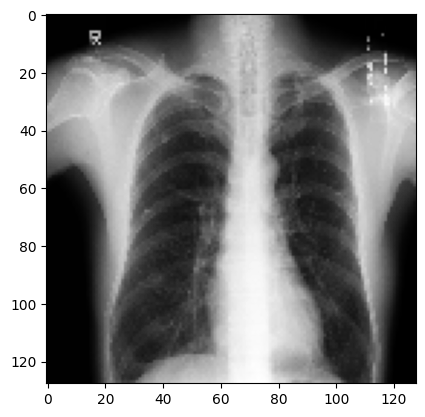

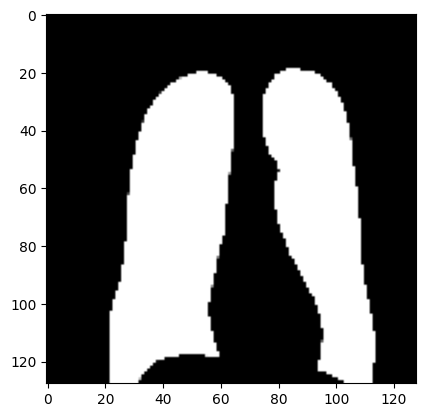

In [21]:
plt.imshow(cxrs[693], cmap='gray')
plt.show()
plt.imshow(masks[693], cmap='gray')
plt.show()

In [22]:
os.makedirs('/kaggle/working/test', exist_ok=True)

with open('/kaggle/working/test/cxrs', 'wb') as lung_segmentation_dataset_cxr:
    np.save(lung_segmentation_dataset_cxr, cxrs)

with open('/kaggle/working/test/masks', 'wb') as lung_segmentation_dataset_mask:
    np.save(lung_segmentation_dataset_mask, masks)

In [23]:
# !rm -rf /kaggle/working/*